> 📝 **Planning note (author use -- remove before publishing)**
>
> **Intended contents:** the generic toolkit, taught before it is needed downstream: slicing and subsetting, averaging/resampling, interpolating, and `xr.corr`.
>
> **To do:**
> - **Rewrite the "A note on `TIME`" section in your own voice** -- it is a draft in mine.
> - Write the `### Averaging and resampling` intro (empty bullet).
> - `#### xarray resampling` is an empty heading -- write it or delete it.
> - Put the correlation number back into the text once you have re-run.

<img src="../../data/images/hiaoos_learning_moored.png" width="300" align="right">

# Slicing, averaging, interpolating, and correlating

- Slicing and subsetting a time series
- Averaging and resampling
- Interpolating
- Correlating two time series

*Notebook 6 of 10 in the series*  
[← 5. Post-processing & QC II](./05_post_proc_qc_offset_and_drift.ipynb) · [7. Derived parameters & T-S space →](./07_T-S_space.ipynb)

In [1]:
import xarray as xr
from kval.data import moored
from matplotlib import pyplot as plt
import pandas as pd
%matplotlib widget

In [2]:
ds = moored.load_nc('../../data/moored_CTD_test_data/intermediate_data/AT800_21_22_CONCERTO_60595_99m_edited.nc')

In [3]:
moored.plot(ds)

___

## A note on `TIME`

Before we start slicing, a little about how time is stored.

In the file, `TIME` is not a date, but a float whose meaning is defined by the `units` attribute (in this case, `Days since 1970-01-01 00:00`). It is a plain number: a count of time units from this fixed reference point. Have a look:

In [4]:
ds.TIME

<xarray.DataArray 'TIME' (TIME: 23694)> Size: 190kB
array([18940.472219, 18940.479163, 18940.486108, ..., 19105.568363,
       19105.575307, 19105.582251], shape=(23694,))
Coordinates:
  * TIME       (TIME) float64 190kB 1.894e+04 1.894e+04 ... 1.911e+04 1.911e+04
    LATITUDE   float32 4B ...
    LONGITUDE  float32 4B ...
Attributes:
    units:     days since 1970-01-01
    calendar:  standard

This is the NetCDF/CF convention, and it is what `moored.load_nc` gives us by default. It is a good way to *store* time  since it is unambiguous, compact, and works across languages. However, it can in some cases be a little awkward to *work* it. It's clunky to ask for "the first week of February" using a number of days since 1970.

`xarray` understands the convention and can decode it into `datetime64` objects. `kval` wraps this in two functions that convert in either direction:

- `moored.time_as_datetime(ds)` -- number → `datetime64`
- `moored.time_as_float(ds)` -- `datetime64` → number

It can be handy to run `moored.time_as_datetime(ds)` if you want to analyse time series data since it makes it easier to acces, slice, data etc. If you want to store data as NetCDF you may want to run `moored.time_as_float(ds)` first.

Let's convert, so the rest of this notebook can address time by date:

In [5]:
ds = moored.time_as_datetime(ds)
ds.TIME

<xarray.DataArray 'TIME' (TIME: 23694)> Size: 190kB
array(['2021-11-09T11:19:59.709985536', '2021-11-09T11:29:59.706066176',
       '2021-11-09T11:39:59.702147072', ..., '2022-04-23T13:38:26.536918784',
       '2022-04-23T13:48:26.532999936', '2022-04-23T13:58:26.529080320'],
      shape=(23694,), dtype='datetime64[ns]')
Coordinates:
  * TIME       (TIME) datetime64[ns] 190kB 2021-11-09T11:19:59.709985536 ... ...
    LATITUDE   float32 4B ...
    LONGITUDE  float32 4B ...

We see that `TIME` now contains `datetime64` objects like `2021-11-09T11:19:59.709985536` instead of float numbers like `18940.472219`.
____

## Slicing and subsetting

Xarray is built around the concept of *labelled coordinates* - i.e. each variable is associated with a particular set of dimensions. 

This makes it very easy to keep track of coordinates along these coordinate axes, including selectognm parts of the data, interpolating, averaging etc. 

#### Select by coordinate value 

To select data at a particular *value* along a dimension, use `sel`. Because `TIME` is a datetime coordinate, we can address it with a date string. (If you had data on a pressure coordinate, you could equally select by pressure, etc.)

`method = 'nearest'` tells `xarray` to give us the closest available sample rather than requiring an exact match.



#### Example: *What was the temperature on Feb 01 at 21:00?*

To answer this, let's select the sample nearest to 21:00 on Feb 1st 2022:

In [6]:
ds_feb_01 = ds.sel(TIME = '2022-02-01 21:00', method = 'nearest')

.. and  print the result:

In [7]:
print(f'Temperature on {ds_feb_01.TIME.values} was {ds_feb_01.TEMP.values:.3f}°C')

Temperature on 2022-02-01T20:59:12.077048064 was 2.654°C


We can also select a **range** instead of just particular points, using what Python calls a `slice`:

> **Note:** unlike the single-point selection above, we don't pass `method` here. A slice doesn't need one: the end points are interpreted as bounds, not as values to be matched.

#### Example: *What was the average salinity measured in the first half of March?*

Let's select all points within a *range* of times: 

In [8]:
time_slice = slice('2022-03-01', '2022-03-15')
ds_half_march = ds.sel(TIME = time_slice)

In [9]:
moored.plot(ds_half_march)

In [10]:
ds_half_march_mean = ds_half_march.PSAL.mean(dim='TIME').values
print(f'Mean practical salinity from all measurements from March 1th through 15th: {ds_half_march_mean:.3f}')

Mean practical salinity from all measurements from March 1th through 15th: 34.869


> ***Note*** this is an average of all measurements collected within this range. In many cases you might want a true time-weighted mean.

#### Select by index

To select a particular index of a dimension, use the function `isel`.

E.g. to select only the 1000th index along the `TIME` dimension: 

In [11]:
ds_ind1000 = ds.isel(TIME = 1000)

..and likewise we can select a range of points using a slice:

In [12]:
slice_index = slice(1000, 1110)
ds_ind1000_1110 = ds.isel(TIME = slice_index)

## Averaging and resampling



- Why average: noise, storage, and putting two instruments on a common time base (notebook 9 depends on this).
- What is lost -- the AT200 record swings by degrees within a day, and daily means erase that entirely.
- The difference between averaging and resampling.

In [13]:
ds_avgd = moored.time_average(ds, '12h')

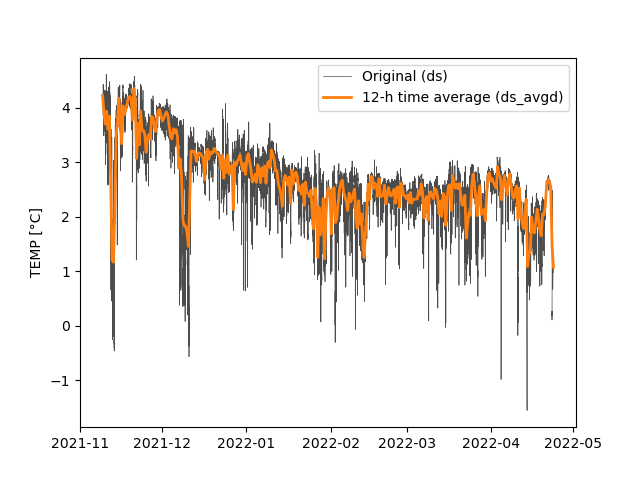

In [14]:
fig, ax = plt.subplots()
ax.plot(ds.TIME, ds.TEMP, label = 'Original (ds)', color = 'k', alpha = 0.7, lw = 0.5)
ax.plot(ds_avgd.TIME, ds_avgd.TEMP, label = '12-h time average (ds_avgd)', color = 'tab:orange', lw = 2)
ax.set_ylabel('TEMP [°C]')
ax.legend()


#### xarray resampling

- `ds.resample()` as the xarray-native alternative to `moored.time_average`.
- When you would reach for one over the other.

## Interpolating

#### Interpolate across data gaps

In some cases, we may want to interpolate across points with no data - i.e. NaNs. To do this, use xarrays `interpolate_na`.

To illustrate, lets make a hole of empty data in our `PRES`:


In [15]:
ds_hole = moored.remove_points(ds, 'PRES', remove_inds = slice(10000, 13000)) 

.. this should set all points in `PRES` between indices 10000 and 13000 to NaN. Let's check with a quick plot:

Text(0, 0.5, 'dbar')

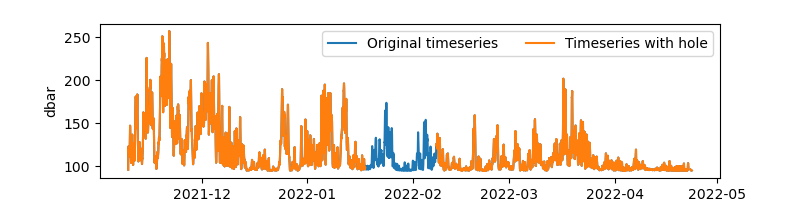

In [17]:
fig, ax = plt.subplots(figsize = (8, 2))
ax.plot(ds.TIME, ds.PRES, label = 'Original timeseries')
ax.plot(ds_hole.TIME, ds_hole.PRES, label = 'Timeseries with hole')
ax.legend(ncol = 2)
ax.set_ylabel('dbar')

Now let's use `interpolate_na` to linearly interpolate over this hole: 

In [18]:
ds_hole_ip = ds_hole.interpolate_na(dim='TIME')

.. and another quick plot to check whether this worked:

Text(0, 0.5, 'dbar')

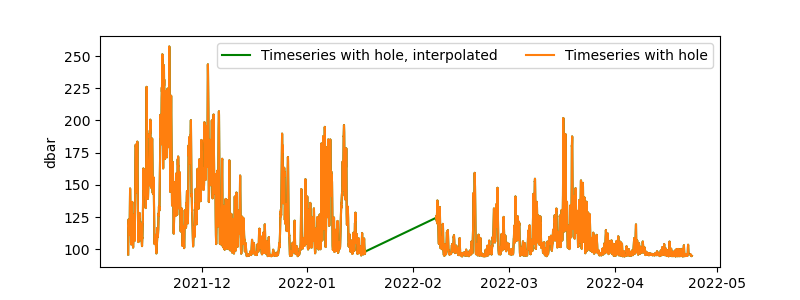

In [19]:
fig, ax = plt.subplots(figsize = (8, 3))
ax.plot(ds_hole_ip.TIME, ds_hole_ip.PRES, 'g', label = 'Timeseries with hole, interpolated')
ax.plot(ds_hole.TIME, ds_hole.PRES, color = 'tab:orange', label = 'Timeseries with hole', )
ax.legend(ncol = 2)
ax.set_ylabel('dbar')

#### Interpolate onto new points

Let's make a new time grid. For the sake of example, a 6-hourly grid spanning Dec 3rd to 6th 2021:

In [20]:
TIME_new = pd.date_range('2021-12-03', '2021-12-06', freq='6h')

Now let's interpolate `ds` onto `TIME_new`:

In [21]:
ds_ip_new = ds.interp(TIME=TIME_new)

Text(0, 0.5, 'dbar')

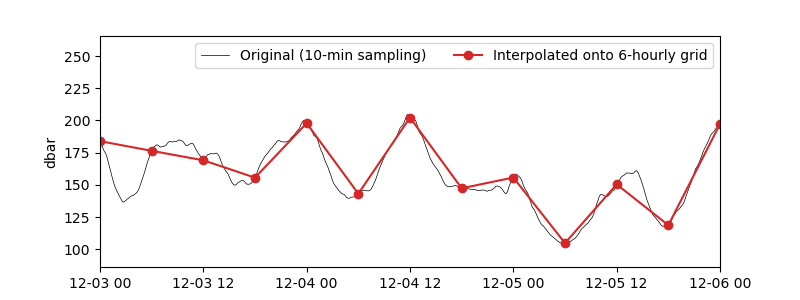

In [22]:
fig, ax = plt.subplots(figsize = (8, 3))
ax.plot(ds.TIME, ds.PRES, color = 'k', lw = 0.5, label = 'Original (10-min sampling)')
ax.plot(ds_ip_new.TIME, ds_ip_new.PRES, 'o-', color = 'tab:red',
        label = 'Interpolated onto 6-hourly grid')
ax.set_xlim(TIME_new[0], TIME_new[-1])
ax.legend(ncol = 2)
ax.set_ylabel('dbar')

## Correlating two time series
For example, let's say we are interested in the correlation between `TEMP` and `PSAL` in our dataset: 

In [23]:
timeseries_1 = ds.TEMP
timeseries_2 = ds.PSAL

In [24]:
r = xr.corr(timeseries_1, timeseries_2)
print(f'r = {r:.3f}')

r = 0.796


The two variables are positively and positively correlated (r=0.796).

This makes physical sense for this dataset, where we often find that `TEMP` and `PSAL` covary as twater masses transition passing by the instrument transitions between warmer, saltier atlantic water and colder, fresher polar surface water. More about that in the next notebook!

>For more complex statistical analysis, look into the `stats` submodule of the [Scipy](https://scipy.org/) package - it is widely used for statistics and machine learning.

___

**Next:** [7. Derived parameters & T-S space →](./07_T-S_space.ipynb)